In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_data=pd.read_csv("unimelb_training.csv",low_memory=False)

In [4]:
train_data.head()

,Grant.Application.ID,Grant.Status,Sponsor.Code,Grant.Category.Code,Contract.Value.Band...see.note.A,Start.date,RFCD.Code.1,RFCD.Percentage.1,RFCD.Code.2,RFCD.Percentage.2,...,Faculty.No..15,With.PHD.15,No..of.Years.in.Uni.at.Time.of.Grant.15,Number.of.Successful.Grant.15,Number.of.Unsuccessful.Grant.15,A..15,A.15,B.15,C.15,Unnamed: 251
0,1,1,NaN,NaN,A,8/11/05,280199.0,100.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,2B,10A,B,11/11/05,280103.0,30.0,280106.0,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,29A,10B,A,14/11/05,321004.0,60.0,321216.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,40D,10B,C,15/11/05,270602.0,50.0,320602.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,59C,10A,A,16/11/05,260500.0,34.0,280000.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score

In [6]:
train_data.shape

(8708, 252)

In [7]:
train_data.describe()

,Grant.Application.ID,Grant.Status,RFCD.Code.1,RFCD.Percentage.1,RFCD.Code.2,RFCD.Percentage.2,RFCD.Code.3,RFCD.Percentage.3,RFCD.Code.4,RFCD.Percentage.4,...,Dept.No..15,Faculty.No..15,With.PHD.15,Number.of.Successful.Grant.15,Number.of.Unsuccessful.Grant.15,A..15,A.15,B.15,C.15,Unnamed: 251
count,8708.000000,8708.000000,8074.000000,8074.000000,8074.000000,8074.000000,8074.000000,8074.000000,8074.000000,8074.000000,...,2.0,2.0,0.0,2.0,2.0,2.00000,2.0,2.0,0.0,0.0
mean,4354.500000,0.458429,314625.121006,75.005251,158842.523161,17.595281,92956.217736,6.883986,6551.696309,0.406490,...,3048.0,31.0,NaN,1.0,0.0,11.50000,3.0,2.0,NaN,NaN
std,2513.927405,0.498297,51817.235580,26.836228,160685.895040,19.438356,146607.359501,11.806640,44953.214321,3.004969,...,0.0,0.0,NaN,0.0,0.0,2.12132,0.0,0.0,NaN,NaN
min,1.000000,0.000000,210000.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3048.0,31.0,NaN,1.0,0.0,10.00000,3.0,2.0,NaN,NaN
25%,2177.750000,0.000000,280204.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3048.0,31.0,NaN,1.0,0.0,10.75000,3.0,2.0,NaN,NaN
50%,4354.500000,0.000000,320704.000000,80.000000,230202.000000,10.000000,0.000000,0.000000,0.000000,0.000000,...,3048.0,31.0,NaN,1.0,0.0,11.50000,3.0,2.0,NaN,NaN
75%,6531.250000,1.000000,321202.000000,100.000000,320700.750000,30.000000,270105.000000,10.000000,0.000000,0.000000,...,3048.0,31.0,NaN,1.0,0.0,12.25000,3.0,2.0,NaN,NaN
max,8708.000000,1.000000,999999.000000,100.000000,440209.000000,90.000000,440207.000000,80.000000,440202.000000,70.000000,...,3048.0,31.0,NaN,1.0,0.0,13.00000,3.0,2.0,NaN,NaN


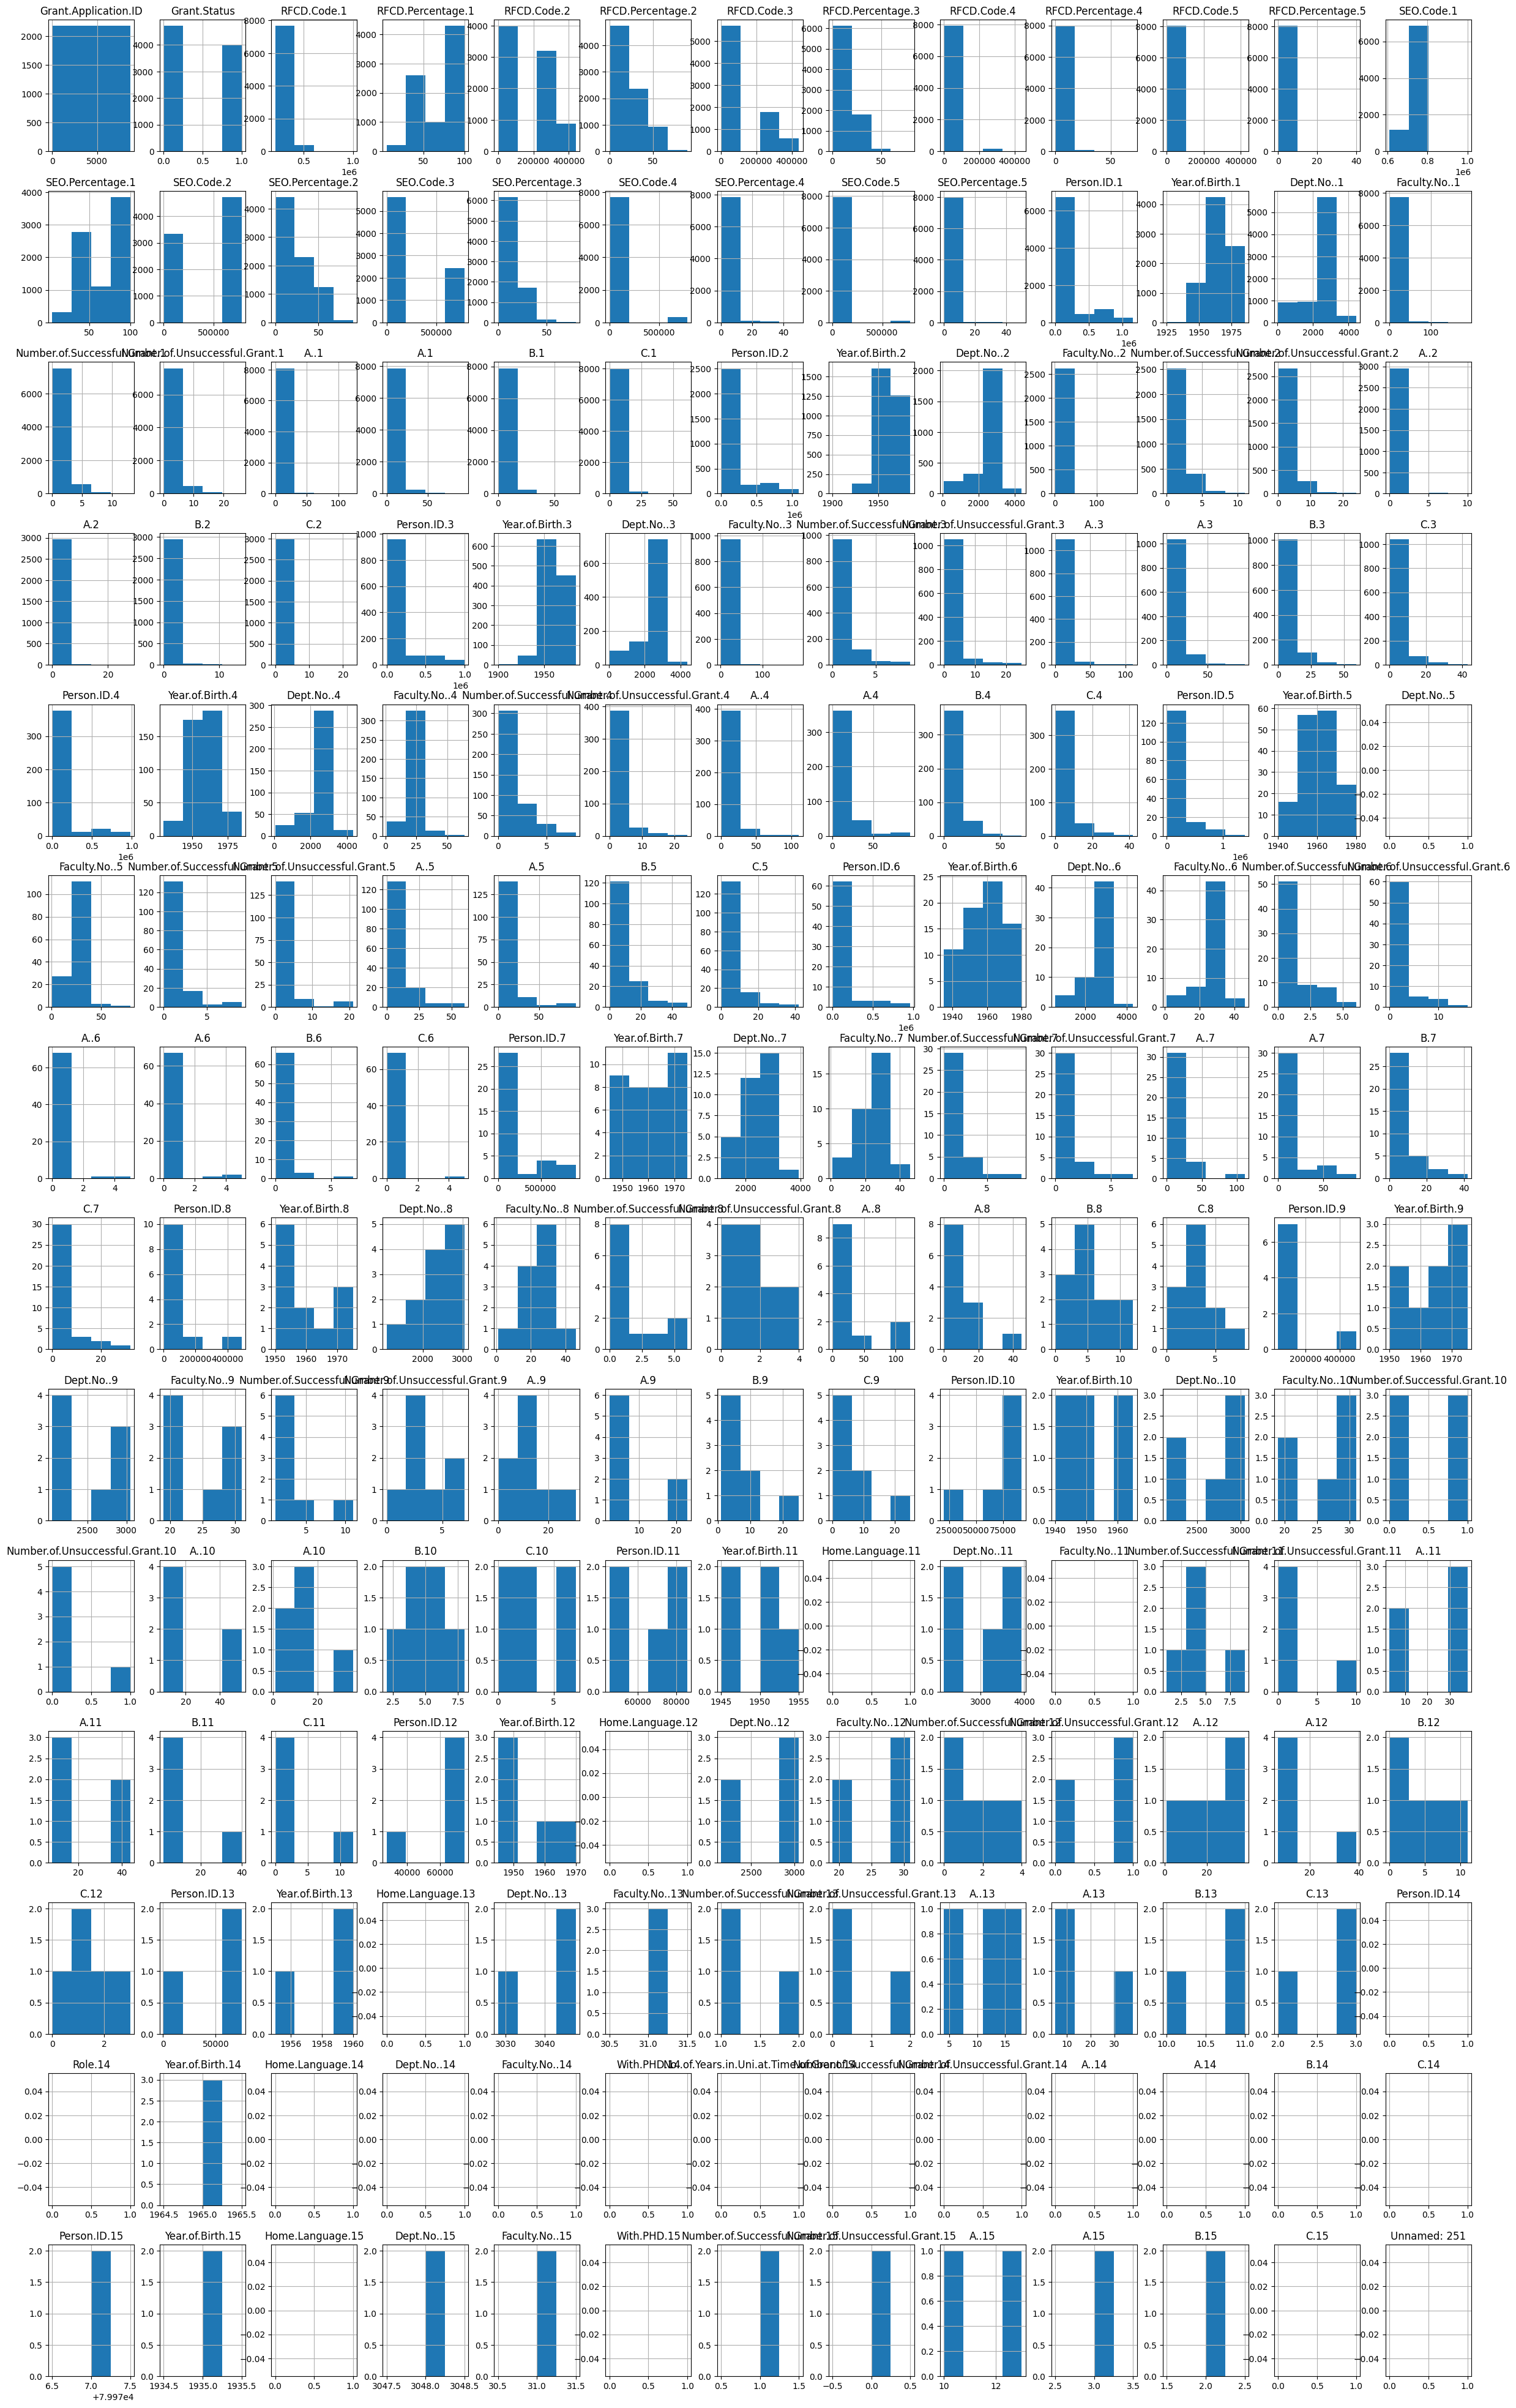

In [10]:
import seaborn as sns
train_data.hist(bins=4, figsize=(30,50))
plt.show()

In [11]:
train_data.columns

Index(['Grant.Application.ID', 'Grant.Status', 'Sponsor.Code',
       'Grant.Category.Code', 'Contract.Value.Band...see.note.A', 'Start.date',
       'RFCD.Code.1', 'RFCD.Percentage.1', 'RFCD.Code.2', 'RFCD.Percentage.2',
       ...
       'Faculty.No..15', 'With.PHD.15',
       'No..of.Years.in.Uni.at.Time.of.Grant.15',
       'Number.of.Successful.Grant.15', 'Number.of.Unsuccessful.Grant.15',
       'A..15', 'A.15', 'B.15', 'C.15', 'Unnamed: 251'],
      dtype='object', length=252)

In [12]:
vars=['Grant.Application.ID','Grant.Status','RFCD.Code.1','RFCD.Percentage.1','RFCD.Code.2','RFCD.Percentage.2','RFCD.Code.3','RFCD.Percentage.3','RFCD.Code.4','RFCD.Percentage.4','RFCD.Code.5','RFCD.Percentage.5','SEO.Code.1','SEO.Percentage.1']

In [16]:
df1 = [col for col in train_data.columns if train_data[col].dtype == 'object']

In [17]:
train_data.dtypes

Grant.Application.ID                  int64
Grant.Status                          int64
Sponsor.Code                         object
Grant.Category.Code                  object
Contract.Value.Band...see.note.A     object
                                     ...   
A..15                               float64
A.15                                float64
B.15                                float64
C.15                                float64
Unnamed: 251                        float64
Length: 252, dtype: object

In [18]:
df1=train_data[vars]

In [19]:
df1.fillna(df1.mean(), inplace= True)

C:\Users\marku\AppData\Local\Temp\ipykernel_15780\1847131300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.fillna(df1.mean(), inplace= True)


In [20]:
df1.columns

Index(['Grant.Application.ID', 'Grant.Status', 'RFCD.Code.1',
       'RFCD.Percentage.1', 'RFCD.Code.2', 'RFCD.Percentage.2', 'RFCD.Code.3',
       'RFCD.Percentage.3', 'RFCD.Code.4', 'RFCD.Percentage.4', 'RFCD.Code.5',
       'RFCD.Percentage.5', 'SEO.Code.1', 'SEO.Percentage.1'],
      dtype='object')

In [21]:
input = [col for col in df1.columns if df1[col].dtype != 'object']

In [22]:
output='Grant.Status'

In [23]:
input.remove(output)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
log1 = LogisticRegression(max_iter=20)

In [26]:
log1.fit(X=df1[input], y=df1[output])

C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,20
,multi_class,'deprecated'


In [27]:
from sklearn.metrics import accuracy_score

In [28]:
preds = log1.predict(X=df1[input])

In [29]:
preds

array([0, 0, 1, ..., 0, 0, 0], shape=(8708,))

In [30]:
print(accuracy_score(y_pred=preds, y_true=df1[output]))

0.5438677078548462


In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
random_forest1 = RandomForestClassifier()

In [33]:
random_forest1.fit(X=df1[input], y=df1[output])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
print(accuracy_score(y_pred=random_forest1.predict(X=df1[input]), y_true=df1[output])*100)

100.0


In [38]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(df1[output], random_forest1.predict(X=df1[input]))
print(confusion_matrix)

[[4716    0]
 [   0 3992]]
